In [1]:
import numpy as np
import pandas as pd
import pickle, json, os
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

In [2]:
import configparser, os

config_path = os.path.expanduser("~/.spynnaker.cfg")
config = configparser.ConfigParser()
config.read(config_path)

if not config.has_section("Reports"):
    config.add_section("Reports")
config.set("Reports", "write_energy_report", "True")

with open(config_path, "w") as f:
    config.write(f)
print("Done")

Done


In [3]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles in current directory:")
for f in sorted(os.listdir(".")):
    print(f"  {f}")

Current working directory:
/mnt/user/shared/NMC test collab for user mamon/spinnaker_export

Files in current directory:
  .ipynb_checkpoints
  X_df.csv
  bad_0
  bad_0.json
  bad_1
  bad_1.json
  bad_1_2
  bad_1_2.json
  bad_2
  bad_2.json
  bad_3
  bad_3.json
  bad_4
  bad_4.json
  bad_reports_fold_-1
  bad_reports_fold_-2
  ebrains_evaluation.ipynb
  fold_0_results_20260516_140347.json
  fold_1
  fold_1_results_20260516_161443.json
  fold_2
  fold_2_results_batchsize_100_20260516_183122.json
  fold_3
  fold_3_results_batchsize_500_20260517_122535.json
  fold_4
  fold_5
  fold_indices.pkl
  global_cfg.json
  job.py
  meta.csv
  reports
  reports_fold_0
  reports_fold_0_v1
  reports_fold_1
  reports_fold_1_v1
  reports_fold_2_batchsize_100
  reports_fold_2_v1
  reports_fold_3_batchsize_500
  reports_fold_3_v1
  reports_fold_4_v1
  roc_curves.png
  training.ipynb
  v1_fold_0_results_20260515_202320.json
  v1_fold_1_results_20260515_211931.json
  v1_fold_2_results_20260515_225428.json
 

In [4]:
import logging

logging.getLogger("spynnaker.pyNN.models.spike_source.spike_source_array_vertex").setLevel(logging.ERROR)

In [5]:
EXPORT_DIR  = "./"
NUM_FOLDS   = 5

with open(f"{EXPORT_DIR}global_cfg.json") as f:
    cfg = json.load(f)

INPUT_SIZE   = cfg["input_size"]
HIDDEN_SIZE  = cfg["HIDDEN_SIZE"]
HIDDEN_SIZE2 = cfg["HIDDEN_SIZE2"]
OUTPUT_SIZE  = cfg["output_size"]
BETA         = cfg["BETA"]
THRESHOLD    = cfg["THRESHOLD"]
NUM_STEPS    = cfg["NUM_STEPS"]

class _SNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(INPUT_SIZE,   HIDDEN_SIZE)
        self.fc2 = nn.Linear(HIDDEN_SIZE,  HIDDEN_SIZE2)
        self.fc3 = nn.Linear(HIDDEN_SIZE2, OUTPUT_SIZE)

fold_weights = {}

for fold_idx in range(1, NUM_FOLDS + 1):
    ckpt = f"{EXPORT_DIR}/fold_{fold_idx}/model.pt"
    m = _SNNModel()
    
    incompatible = m.load_state_dict(
        torch.load(ckpt, map_location="cpu", weights_only=False),
        strict=False
    )
    m.eval()

    if incompatible.missing_keys:
        print(f"Fold {fold_idx}: WARNING missing keys: {incompatible.missing_keys}")
    else:
        print(f"Fold {fold_idx}: fc weights loaded OK, "
              f"ignored snntorch keys: {incompatible.unexpected_keys}")

    fold_weights[fold_idx-1] = {
        "W1": m.fc1.weight.detach().numpy(),
        "b1": m.fc1.bias.detach().numpy(),
        "W2": m.fc2.weight.detach().numpy(),
        "b2": m.fc2.bias.detach().numpy(),
        "W3": m.fc3.weight.detach().numpy(),
        "b3": m.fc3.bias.detach().numpy(),
    }
    print(f"         W1={fold_weights[fold_idx-1]['W1'].shape}  "
          f"W2={fold_weights[fold_idx-1]['W2'].shape}  "
          f"W3={fold_weights[fold_idx-1]['W3'].shape}")

Fold 1: fc weights loaded OK, ignored snntorch keys: ['lif1.threshold', 'lif1.graded_spikes_factor', 'lif1.reset_mechanism_val', 'lif1.beta', 'lif2.threshold', 'lif2.graded_spikes_factor', 'lif2.reset_mechanism_val', 'lif2.beta']
         W1=(128, 399)  W2=(64, 128)  W3=(2, 64)
Fold 2: fc weights loaded OK, ignored snntorch keys: ['lif1.threshold', 'lif1.graded_spikes_factor', 'lif1.reset_mechanism_val', 'lif1.beta', 'lif2.threshold', 'lif2.graded_spikes_factor', 'lif2.reset_mechanism_val', 'lif2.beta']
         W1=(128, 399)  W2=(64, 128)  W3=(2, 64)
Fold 3: fc weights loaded OK, ignored snntorch keys: ['lif1.threshold', 'lif1.graded_spikes_factor', 'lif1.reset_mechanism_val', 'lif1.beta', 'lif2.threshold', 'lif2.graded_spikes_factor', 'lif2.reset_mechanism_val', 'lif2.beta']
         W1=(128, 399)  W2=(64, 128)  W3=(2, 64)
Fold 4: fc weights loaded OK, ignored snntorch keys: ['lif1.threshold', 'lif1.graded_spikes_factor', 'lif1.reset_mechanism_val', 'lif1.beta', 'lif2.threshold', 'li

In [6]:
import os, json, pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, classification_report, confusion_matrix)

EXPORT_DIR = "."

with open(f"{EXPORT_DIR}/global_cfg.json") as f:
    cfg = json.load(f)

INPUT_SIZE   = cfg["input_size"]
HIDDEN_SIZE  = cfg["HIDDEN_SIZE"]
HIDDEN_SIZE2 = cfg["HIDDEN_SIZE2"]
OUTPUT_SIZE  = cfg["output_size"]
BETA         = cfg["BETA"]
THRESHOLD    = cfg["THRESHOLD"]
NUM_STEPS    = cfg["NUM_STEPS"]

X_df  = pd.read_csv(f"{EXPORT_DIR}/X_df.csv")
y_ser = pd.read_csv(f"{EXPORT_DIR}/y_ser.csv")["label"]
meta  = pd.read_csv(f"{EXPORT_DIR}/meta.csv")

with open(f"{EXPORT_DIR}/fold_indices.pkl", "rb") as f:
    fold_indices = pickle.load(f)


FOLD_IDX = 4

fold_indices = [fold_indices[FOLD_IDX]]
print(f"X shape : {X_df.shape}")
print(f"y shape : {y_ser.shape}")
print(f"Folds   : {len(fold_indices)}")
print(f"Config  : {cfg}")

X shape : (20516, 399)
y shape : (20516,)
Folds   : 1
Config  : {'CODING_METHOD': 'latency', 'BETA': 0.9, 'LEARNING_RATE': 0.0005, 'NUM_STEPS': 70, 'HIDDEN_SIZE': 128, 'HIDDEN_SIZE2': 64, 'NUM_EPOCHS': 100, 'THRESHOLD': 0.3, 'GAIN': 1.0, 'PATIENCE': 20, 'input_size': 399, 'output_size': 2}


In [7]:
def latency_spike_times(x_scaled: np.ndarray, num_steps: int):
    """
    x_scaled : 1D array [n_features], StandardScaler-transformed
    Returns  : list of length n_features
               each element is a list with one spike time (ms), or [] if clamped to zero
    Matches latency_encode_manual() from your training notebook exactly.
    """
    x_clipped  = np.clip(x_scaled, -4, 4)
    x_norm     = (x_clipped + 4) / 8
    spike_step = ((1.0 - x_norm) * (num_steps - 1)).astype(int)
    spike_step = np.clip(spike_step, 0, num_steps - 1)
    return [[float(spike_step[f])] for f in range(len(x_scaled))]

In [8]:
import subprocess
import requests, os

def refresh_ebrains_token():
    """Fetch a fresh EBRAINS bearer token from the JupyterHub access-token service."""
    try:
        jupyter_token = os.getenv("JUPYTERHUB_API_TOKEN")
        jupyter_ip    = os.getenv("JUPYTERHUB_SERVICE_HOST")
        jupyter_port  = os.getenv("JUPYTERHUB_SERVICE_PORT")
        url = f"http://{jupyter_ip}:{jupyter_port}/services/access-token-service/access-token"
        token = requests.get(
            url,
            headers={"Authorization": f"Token {jupyter_token}"},
            timeout=10
        ).json().get("access_token")
        if token:
            os.environ["OIDC_BEARER_TOKEN"] = token
            print("Token refreshed OK")
        else:
            print("WARNING: Token response was empty")
    except Exception as e:
        print(f"Token refresh failed: {e}")

In [9]:
import logging

for logger_name in ['spinn_utilities', 'spinn_machine', 'pacman', 'spinnman', 
                   'spinn_front_end_common', 'spynnaker']:
    logging.getLogger(logger_name).setLevel(logging.ERROR)

In [10]:
window = NUM_STEPS

In [11]:
import configparser
import os

config_path = os.path.expanduser("~/.spynnaker.cfg")

config = configparser.ConfigParser()

# Read existing config if it exists
if os.path.exists(config_path):
    config.read(config_path)

# Disable Java
if not config.has_section("Java"):
    config.add_section("Java")
config.set("Java", "use_java", "False")

with open(config_path, "w") as f:
    config.write(f)

print(f"Config written to {config_path}")

Config written to /opt/app-root/src/.spynnaker.cfg


In [12]:
import spynnaker.pyNN as sim

BATCH_SIZE = 500
# FIX 2a: drain gap so membrane resets between samples
_tau_m_const  = -1.0 / np.log(cfg["BETA"])
DRAIN_GAP     = int(np.ceil(5 * _tau_m_const)) + 1   # ~48 ms for BETA=0.9
SAMPLE_STRIDE = NUM_STEPS + DRAIN_GAP                 # total ms allocated per sample

fold_results = []

for _fold_idx, (train_idx, test_idx) in enumerate(fold_indices, start=1):
    print(f"\n{'='*50}")
    print(f"Fold {FOLD_IDX}")

    weights = fold_weights[FOLD_IDX]
    scaler  = StandardScaler()
    scaler.fit(X_df.iloc[train_idx].values.astype(np.float32))

    X_test    = X_df.iloc[test_idx].values.astype(np.float32)
    y_test    = y_ser.iloc[test_idx].reset_index(drop=True)
    meta_test = meta.iloc[test_idx].reset_index(drop=True)
    X_test_sc = scaler.transform(X_test)

    n_samples = len(X_test_sc)
    n_batches = int(np.ceil(n_samples / BATCH_SIZE))
    print(f"Samples: {n_samples} | Batch size: {BATCH_SIZE} | Batches: {n_batches}")
    print(f"SAMPLE_STRIDE: {SAMPLE_STRIDE} ms (window={window} + drain={DRAIN_GAP})")

    y_pred  = []
    y_proba = []

    fold_sops        = 0
    fold_sop_energy  = 0.0
    fold_sparsity_h1 = []
    fold_sparsity_h2 = []

    for batch_idx in range(n_batches):
        refresh_ebrains_token()

        b_start    = batch_idx * BATCH_SIZE
        b_end      = min(b_start + BATCH_SIZE, n_samples)
        batch      = X_test_sc[b_start:b_end]
        n_in_batch = len(batch)

        # FIX 2b: total_time uses SAMPLE_STRIDE, not window
        total_time = SAMPLE_STRIDE * n_in_batch

        print(f"  Batch {batch_idx+1}/{n_batches} "
              f"(samples {b_start}–{b_end}, {total_time} ms)...")

        # FIX 2b: spike offsets use SAMPLE_STRIDE so input spikes land
        #         in the correct window and don't bleed into the drain gap
        all_spike_times = [[] for _ in range(cfg["input_size"])]
        for i, x in enumerate(batch):
            offset = i * SAMPLE_STRIDE
            for f, times in enumerate(latency_spike_times(x, window)):
                if times:
                    all_spike_times[f].append(float(offset + times[0]))

        for f in range(cfg["input_size"]):
            if not all_spike_times[f]:
                all_spike_times[f] = [-1.0]

        sim.setup(timestep=1.0)

        tau_m   = -1.0 / np.log(cfg["BETA"])
        tau_syn = 1.0

        lif_params = dict(
            tau_m=tau_m, tau_syn_E=tau_syn, tau_syn_I=tau_syn,
            v_thresh=cfg["THRESHOLD"], v_reset=0.0, v_rest=0.0,
            cm=1.0, tau_refrac=0.1,
        )
        # FIX 1: output layer must never spike — it is a non-spiking integrator
        #        matching fc3 -> mem3_rec in training (no lif3 exists there)
        out_params = {**lif_params, "v_thresh": 30000.0}

        # --- populations ---
        input_pop = sim.Population(cfg["input_size"],
                                   sim.SpikeSourceArray(spike_times=all_spike_times))

        hidden1 = sim.Population(cfg["HIDDEN_SIZE"],  sim.IF_curr_exp(**lif_params))
        hidden2 = sim.Population(cfg["HIDDEN_SIZE2"], sim.IF_curr_exp(**lif_params))
        # FIX 1: use out_params (v_thresh=30000.0) so output membrane never resets
        output  = sim.Population(cfg["output_size"],  sim.IF_curr_exp(**out_params))

        # FIX 3: bias fires only during each sample's active window,
        #        NOT during the drain gap — matches training where bias
        #        is added once per timestep per sample, not globally
        bias_times = [[
            float(i * SAMPLE_STRIDE + t)
            for i in range(n_in_batch)
            for t in range(window)
        ]]

        bias1 = sim.Population(1, sim.SpikeSourceArray(spike_times=bias_times))
        bias2 = sim.Population(1, sim.SpikeSourceArray(spike_times=bias_times))
        bias3 = sim.Population(1, sim.SpikeSourceArray(spike_times=bias_times))

        # --- weight projection helper ---
        def _project(pre, post, W):
            W = W.T
            # FIX 5: scale by 1/tau_syn to match analog weight magnitude in training
            scale = 1.0 / tau_syn
            exc = [(i, j, float( W[i,j]) * scale, 1.0)
                   for i in range(W.shape[0]) for j in range(W.shape[1]) if  W[i,j] > 1e-6]
            inh = [(i, j, float(-W[i,j]) * scale, 1.0)
                   for i in range(W.shape[0]) for j in range(W.shape[1]) if -W[i,j] > 1e-6]
            if exc:
                sim.Projection(pre, post, sim.FromListConnector(exc),
                               synapse_type=sim.StaticSynapse(), receptor_type="excitatory")
            if inh:
                sim.Projection(pre, post, sim.FromListConnector(inh),
                               synapse_type=sim.StaticSynapse(), receptor_type="inhibitory")

        # --- bias projection helper ---
        def _project_bias(bias_pop, post, b_vec):
            # FIX 4: scale by 1/tau_syn to match analog bias addition in training
            scale = 1.0 / tau_syn
            exc = [(0, j, float( b_vec[j]) * scale, 1.0) for j in range(len(b_vec)) if  b_vec[j] > 1e-6]
            inh = [(0, j, float(-b_vec[j]) * scale, 1.0) for j in range(len(b_vec)) if -b_vec[j] > 1e-6]
            if exc:
                sim.Projection(bias_pop, post, sim.FromListConnector(exc),
                               synapse_type=sim.StaticSynapse(), receptor_type="excitatory")
            if inh:
                sim.Projection(bias_pop, post, sim.FromListConnector(inh),
                               synapse_type=sim.StaticSynapse(), receptor_type="inhibitory")

        # --- connect weights ---
        _project(input_pop, hidden1, weights["W1"])
        _project(hidden1,   hidden2, weights["W2"])
        _project(hidden2,   output,  weights["W3"])

        # --- connect biases ---
        _project_bias(bias1, hidden1, weights["b1"])
        _project_bias(bias2, hidden2, weights["b2"])
        _project_bias(bias3, output,  weights["b3"])

        # no need to record spikes from output — it never spikes (v_thresh=30000.0)
        hidden1.record(["spikes"])
        hidden2.record(["spikes"])
        output.record(["v"])

        sim.run(total_time)

        v_data  = output.get_data("v").segments[0].analogsignals[0]
        v_array = np.array(v_data)

        # --- SOP-based energy calculation (Furber et al. 2014) ---
        spikes_h1 = hidden1.get_data("spikes").segments[0].spiketrains
        spikes_h2 = hidden2.get_data("spikes").segments[0].spiketrains
        
        n_spikes_h1 = sum(len(st) for st in spikes_h1)
        n_spikes_h2 = sum(len(st) for st in spikes_h2)
        
        # each spike in h1 drives HIDDEN_SIZE2 synapses, each in h2 drives OUTPUT_SIZE
        sops = n_spikes_h1 * cfg["HIDDEN_SIZE2"] + n_spikes_h2 * cfg["output_size"]
        
        E_per_SOP_pJ = 26.0  # Furber et al. 2014, SpiNNaker synaptic event energy
        batch_energy_J = sops * E_per_SOP_pJ * 1e-12
        
        sparsity_h1 = n_spikes_h1 / (cfg["HIDDEN_SIZE"]  * n_in_batch * window)
        sparsity_h2 = n_spikes_h2 / (cfg["HIDDEN_SIZE2"] * n_in_batch * window)
        
        print(f"    SOPs: {sops:,}  |  Energy: {batch_energy_J:.6f} J  |  "
              f"Sparsity h1={sparsity_h1:.3f} h2={sparsity_h2:.3f}")

        batch_preds  = []
        batch_probas = []

        for i in range(n_in_batch):
            # FIX 2b: slice window starting at SAMPLE_STRIDE offset, not window offset
            t_start  = i * SAMPLE_STRIDE
            t_end    = t_start + window          # only the active window, skip drain gap

            v_window = v_array[t_start:t_end, :]  # [window, 2]

            # same time-weighted sum as training
            T = v_window.shape[0]
            time_weights = np.exp(-np.arange(T).astype(float) / (T / 3))
            time_weights /= time_weights.sum()
            out = (v_window * time_weights[:, None]).sum(axis=0)  # [2]

            pred = int(np.argmax(out))

            # softmax for probability
            out_shifted = out - out.max()
            exp_out = np.exp(out_shifted)
            proba_c = float(exp_out[1] / exp_out.sum())

            batch_preds.append(pred)
            batch_probas.append(proba_c)

        fold_sops       += sops
        fold_sop_energy += batch_energy_J
        fold_sparsity_h1.append(sparsity_h1)
        fold_sparsity_h2.append(sparsity_h2)

        sim.end()

        y_pred.extend(batch_preds)
        y_proba.extend(batch_probas)

        y_true_batch = y_test.iloc[b_start:b_end].values
        batch_acc = accuracy_score(y_true_batch, batch_preds)
        batch_bal = balanced_accuracy_score(y_true_batch, batch_preds)
        cum_acc   = accuracy_score(y_test.iloc[:len(y_pred)], y_pred)

        print(f"    Batch Acc: {batch_acc:.4f} | BalAcc: {batch_bal:.4f} | CumAcc: {cum_acc:.4f}")

    y_true = np.asarray(y_test)
    y_pred = np.array(y_pred)

    acc     = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    f1      = f1_score(y_true, y_pred, average="macro")

    print(f"\n[Window] Fold {FOLD_IDX}  Acc={acc:.4f}  BalAcc={bal_acc:.4f}  F1={f1:.4f}")

    df_pred = meta_test.copy()
    df_pred["y_true"]  = y_true
    df_pred["y_pred"]  = y_pred
    df_pred["proba_C"] = y_proba

    subj = df_pred.groupby("participant_id").apply(
        lambda g: pd.Series({
            "y_true": int(g["y_true"].mode()[0]),
            "y_pred": int(g["y_pred"].mode()[0]),
        })
    ).reset_index()

    subj_proba = df_pred.groupby("participant_id")["proba_C"].mean().values

    acc_s = accuracy_score(subj["y_true"], subj["y_pred"])
    bal_s = balanced_accuracy_score(subj["y_true"], subj["y_pred"])
    f1_s  = f1_score(subj["y_true"], subj["y_pred"], average="macro")

    print(f"[Subj]   Fold {FOLD_IDX}  Acc={acc_s:.4f}  BalAcc={bal_s:.4f}  F1={f1_s:.4f}")

    fold_results.append({
        "fold": FOLD_IDX,

        "win_acc": acc,
        "win_bal_acc": bal_acc,
        "win_f1": f1,
        "win_ytrue": y_true.tolist(),
        "win_proba": y_proba,

        "subj_acc": acc_s,
        "subj_bal_acc": bal_s,
        "subj_f1": f1_s,
        "subj_ytrue": subj["y_true"].tolist(),
        "subj_proba": subj_proba.tolist(),

        "sop_energy_J":  fold_sop_energy,
        "total_sops":    fold_sops,
        "sparsity_h1":   float(np.mean(fold_sparsity_h1)),
        "sparsity_h2":   float(np.mean(fold_sparsity_h2)),
    })


Fold 4
Samples: 4124 | Batch size: 500 | Batches: 9
SAMPLE_STRIDE: 119 ms (window=70 + drain=49)
Token refreshed OK
  Batch 1/9 (samples 0–500, 59500 ms)...
['/srv/main-spack-instance-2502/ebrains-spack-builds/vendor/spack/var/spack/environments/ebrains-25-02/.spack-env/view/lib/python3.11/site-packages/spinn_utilities/spinn_utilities.cfg', '/srv/main-spack-instance-2502/ebrains-spack-builds/vendor/spack/var/spack/environments/ebrains-25-02/.spack-env/view/lib/python3.11/site-packages/spinn_machine/spinn_machine.cfg', '/srv/main-spack-instance-2502/ebrains-spack-builds/vendor/spack/var/spack/environments/ebrains-25-02/.spack-env/view/lib/python3.11/site-packages/pacman/pacman.cfg', '/srv/main-spack-instance-2502/ebrains-spack-builds/vendor/spack/var/spack/environments/ebrains-25-02/.spack-env/view/lib/python3.11/site-packages/spinnman/spinnman.cfg', '/srv/main-spack-instance-2502/ebrains-spack-builds/vendor/spack/var/spack/environments/ebrains-25-02/.spack-env/view/lib/python3.11/site

Adding Splitter selectors where appropriate
|0%                          50%                         100%|
Adding delay extensions as required
|0%                          50%                         100%|
Partitioning Graph
|0%                          50%                         100%|
Reading details from 48 chips
|0%                          50%                         100%|
Adding commands
|0%                          50%                         100%|
Adding Chip power monitors to Graph
|0%                          50%                         100%|
Inserting extra monitors into graphs
|0%                          50%                         100%|
Placing Vertices
|0%                          50%                         100%|
Generating routing tables for data in system processes
|0%                          50%                         100%|
Routing
|0%                          50%                         100%|
Allocating tags
|0%                          50%                        

    SOPs: 12,027,122  |  Energy: 0.000313 J  |  Sparsity h1=0.039 h2=0.186


/srv/main-spack-instance-2502/ebrains-spack-builds/vendor/spack/var/spack/environments/ebrains-25-02/.spack-env/view/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


    Batch Acc: 0.6300 | BalAcc: 0.6300 | CumAcc: 0.6300
Token refreshed OK
  Batch 2/9 (samples 500–1000, 59500 ms)...
['/srv/main-spack-instance-2502/ebrains-spack-builds/vendor/spack/var/spack/environments/ebrains-25-02/.spack-env/view/lib/python3.11/site-packages/spinn_utilities/spinn_utilities.cfg', '/srv/main-spack-instance-2502/ebrains-spack-builds/vendor/spack/var/spack/environments/ebrains-25-02/.spack-env/view/lib/python3.11/site-packages/spinn_machine/spinn_machine.cfg', '/srv/main-spack-instance-2502/ebrains-spack-builds/vendor/spack/var/spack/environments/ebrains-25-02/.spack-env/view/lib/python3.11/site-packages/pacman/pacman.cfg', '/srv/main-spack-instance-2502/ebrains-spack-builds/vendor/spack/var/spack/environments/ebrains-25-02/.spack-env/view/lib/python3.11/site-packages/spinnman/spinnman.cfg', '/srv/main-spack-instance-2502/ebrains-spack-builds/vendor/spack/var/spack/environments/ebrains-25-02/.spack-env/view/lib/python3.11/site-packages/spinn_front_end_common/interf

...

/srv/main-spack-instance-2502/ebrains-spack-builds/vendor/spack/var/spack/environments/ebrains-25-02/.spack-env/view/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


    Batch Acc: 0.6180 | BalAcc: 0.6180 | CumAcc: 0.6520
Token refreshed OK
  Batch 9/9 (samples 4000–4124, 14756 ms)...
['/srv/main-spack-instance-2502/ebrains-spack-builds/vendor/spack/var/spack/environments/ebrains-25-02/.spack-env/view/lib/python3.11/site-packages/spinn_utilities/spinn_utilities.cfg', '/srv/main-spack-instance-2502/ebrains-spack-builds/vendor/spack/var/spack/environments/ebrains-25-02/.spack-env/view/lib/python3.11/site-packages/spinn_machine/spinn_machine.cfg', '/srv/main-spack-instance-2502/ebrains-spack-builds/vendor/spack/var/spack/environments/ebrains-25-02/.spack-env/view/lib/python3.11/site-packages/pacman/pacman.cfg', '/srv/main-spack-instance-2502/ebrains-spack-builds/vendor/spack/var/spack/environments/ebrains-25-02/.spack-env/view/lib/python3.11/site-packages/spinnman/spinnman.cfg', '/srv/main-spack-instance-2502/ebrains-spack-builds/vendor/spack/var/spack/environments/ebrains-25-02/.spack-env/view/lib/python3.11/site-packages/spinn_front_end_common/inter

Adding Splitter selectors where appropriate
|0%                          50%                         100%|
Adding delay extensions as required
|0%                          50%                         100%|
Partitioning Graph
|0%                          50%                         100%|
Reading details from 47 chips
|0%                          50%                         100%|
Adding commands
|0%                          50%                         100%|
Adding Chip power monitors to Graph
|0%                          50%                         100%|
Inserting extra monitors into graphs
|0%                          50%                         100%|
Placing Vertices
|0%                          50%                         100%|
Generating routing tables for data in system processes
|0%                          50%                         100%|
Routing
|0%                          50%                         100%|
Allocating tags
|0%                          50%                        

    SOPs: 3,108,648  |  Energy: 0.000081 J  |  Sparsity h1=0.041 h2=0.188
    Batch Acc: 0.3145 | BalAcc: 0.3145 | CumAcc: 0.6419

[Window] Fold 4  Acc=0.6419  BalAcc=0.6831  F1=0.6283
[Subj]   Fold 4  Acc=0.6923  BalAcc=0.7083  F1=0.6750


/srv/main-spack-instance-2502/ebrains-spack-builds/vendor/spack/var/spack/environments/ebrains-25-02/.spack-env/view/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/tmp/ipykernel_16924/2086931277.py:225: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subj = df_pred.groupby("participant_id").apply(


In [13]:
import json, os
from datetime import datetime

out_path = f"./fold_{FOLD_IDX}_results_batchsize_{BATCH_SIZE}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
with open(out_path, "w") as fh:
    json.dump(fold_results[-1], fh, indent=2, 
              default=lambda x: x.tolist() if hasattr(x, 'tolist') else float(x))
print(f"Saved: {out_path}")
print(f"  SOP energy : {fold_results[-1]['sop_energy_J']:.6f} J")
print(f"  Total SOPs : {fold_results[-1]['total_sops']:,}")
print(f"  Sparsity h1: {fold_results[-1]['sparsity_h1']:.3f}")
print(f"  Sparsity h2: {fold_results[-1]['sparsity_h2']:.3f}")

Saved: ./fold_4_results_batchsize_500_20260518_013418.json
  SOP energy : 0.002628 J
  Total SOPs : 101,061,454
  Sparsity h1: 0.040
  Sparsity h2: 0.187


In [14]:
from sklearn.metrics import roc_auc_score, confusion_matrix

results_df = pd.DataFrame(fold_results)
metric_cols = ["win_acc", "win_bal_acc", "win_f1", "subj_acc", "subj_bal_acc", "subj_f1"]

print("=== SpiNNaker Evaluation Summary ===\n")
print(results_df[["fold"] + metric_cols].to_string(index=False))

print("\n--- Mean ± Std ---")
for col in metric_cols:
    m, s = results_df[col].mean(), results_df[col].std()
    print(f"  {col:<16}: {m:.4f} ± {s:.4f}")

print("\n--- AUC-ROC ---")
win_aucs, subj_aucs = [], []
for row in fold_results:
    w_auc = roc_auc_score(row["win_ytrue"],  row["win_proba"])
    s_auc = roc_auc_score(row["subj_ytrue"], row["subj_proba"])
    win_aucs.append(w_auc)
    subj_aucs.append(s_auc)
    print(f"  Fold {row['fold']}  win_auc={w_auc:.4f}  subj_auc={s_auc:.4f}")
print(f"\n  win_auc  mean: {np.mean(win_aucs):.4f} ± {np.std(win_aucs):.4f}")
print(f"  subj_auc mean: {np.mean(subj_aucs):.4f} ± {np.std(subj_aucs):.4f}")

print("\n--- Confusion Matrices per Fold ---")
for row in fold_results:
    win_cm  = confusion_matrix(row["win_ytrue"],  np.round(row["win_proba"]).astype(int))
    subj_cm = confusion_matrix(row["subj_ytrue"], np.round(row["subj_proba"]).astype(int))
    print(f"\nFold {row['fold']}")
    print("  Window-level:\n",  win_cm)
    print("  Subject-level:\n", subj_cm)

=== SpiNNaker Evaluation Summary ===

 fold  win_acc  win_bal_acc   win_f1  subj_acc  subj_bal_acc  subj_f1
    4 0.641853     0.683132 0.628317  0.692308      0.708333    0.675

--- Mean ± Std ---
  win_acc         : 0.6419 ± nan
  win_bal_acc     : 0.6831 ± nan
  win_f1          : 0.6283 ± nan
  subj_acc        : 0.6923 ± nan
  subj_bal_acc    : 0.7083 ± nan
  subj_f1         : 0.6750 ± nan

--- AUC-ROC ---
  Fold 4  win_auc=0.7771  subj_auc=0.8056

  win_auc  mean: 0.7771 ± 0.0000
  subj_auc mean: 0.8056 ± 0.0000

--- Confusion Matrices per Fold ---

Fold 4
  Window-level:
 [[ 930  261]
 [1216 1717]]
  Subject-level:
 [[3 1]
 [3 6]]


In [15]:
import glob

for report_dir in sorted(glob.glob("./reports/*"), reverse=True)[:2]:
    print(f"\n{'='*60}")
    print(f"Run: {report_dir}")
    
    summary = glob.glob(f"{report_dir}/**/summary_energy_report.rpt", recursive=True)
    detailed = glob.glob(f"{report_dir}/**/detailed_energy_report.rpt", recursive=True)
    
    for f in summary:
        print(f"\n--- SUMMARY ---")
        print(open(f).read())
    
    for f in detailed:
        print(f"\n--- DETAILED ---")
        print(open(f).read())


Run: ./reports/2026-05-18-01-31-12-858426

--- SUMMARY ---
Summary energy file
-------------------

Energy used by chips during runtime is 276.28038720000575 Joules (over 14.756 seconds)
Energy used by FPGAs is 0.0 Joules over the entire time the machine was booted (over 94.317362 seconds)
Energy used by FPGAs is 0.0 Joules over the runtime period (over 14.756 seconds)
Energy used by outside router / cooling during the runtime period is 1726.452 Joules
Energy used by packet transmissions is 0.0 Joules (over 125.99183500000001 seconds)
Energy used during the mapping process is 3705.913341 Joules (over 31.674473 seconds)
Energy used by the data generation process is 0.0 Joules (over 0.0 milliseconds)
Energy used during the loading process is 4564.50378604996 Joules (over 27.086256000000002 seconds)
Energy used during the data extraction process is 11432.963484804037 Joules (over 67.231106 seconds)
Total energy used by the simulation over 125991.835 milliseconds is:
     21706.1129990540

In [16]:
import glob, os

report_dirs = sorted(glob.glob("./reports/*"))
print(f"Total report folders: {len(report_dirs)}")
for d in report_dirs:
    summary = glob.glob(f"{d}/**/summary_energy_report.rpt", recursive=True)
    print(f"  {os.path.basename(d)}  {'✓ energy' if summary else '✗ no energy'}")

Total report folders: 10
  2026-05-17-23-31-36-059149  ✗ no energy
  2026-05-18-00-46-19-900227  ✓ energy
  2026-05-18-00-51-52-859640  ✓ energy
  2026-05-18-00-57-30-344994  ✓ energy
  2026-05-18-01-03-05-393529  ✓ energy
  2026-05-18-01-08-54-608416  ✓ energy
  2026-05-18-01-14-36-743443  ✓ energy
  2026-05-18-01-20-08-315814  ✓ energy
  2026-05-18-01-25-51-077966  ✓ energy
  2026-05-18-01-31-12-858426  ✓ energy


In [17]:
import shutil, glob, os

dest = f"./reports_fold_{FOLD_IDX}_batchsize_{BATCH_SIZE}"
os.makedirs(dest, exist_ok=True)

dirs = glob.glob("./reports/*")
for d in dirs:
    shutil.move(d, os.path.join(dest, os.path.basename(d)))
print(f"Moved {len(dirs)} report folders to {dest}/")

Moved 10 report folders to ./reports_fold_4_batchsize_500/


✅ Successfully loaded 5 folds from current directory.


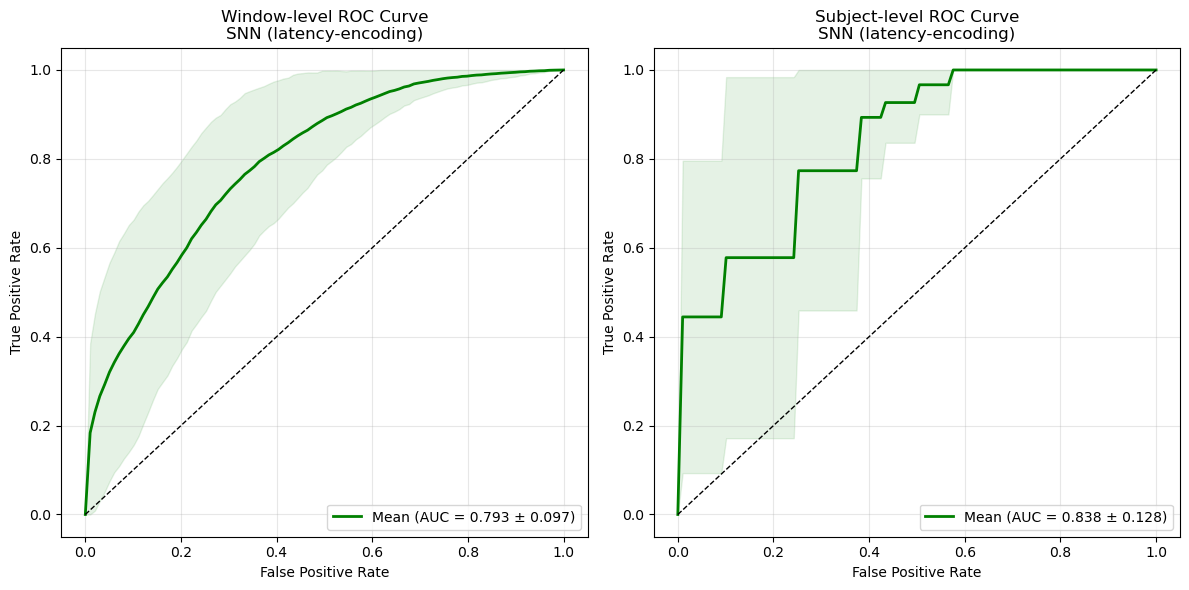

In [14]:
import os
import re
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, auc

# 1. Load the files that actually exist in this directory
fold_files = sorted(glob.glob("./v1_fold_*_results*.json"))
fold_results = []
for f in fold_files:
    with open(f) as file:
        data = json.load(file)
    match = re.search(r"v1_fold_(\d+)_results", os.path.basename(f))
    if match:
        data["fold"] = int(match.group(1))
    fold_results.append(data)

print(f"✅ Successfully loaded {len(fold_results)} folds from current directory.")

if not fold_results:
    raise RuntimeError("No fold result files found! Please check your filenames.")

# Shared False Positive Rate space for mean curve interpolation
mean_fpr = np.linspace(0, 1, 100)

# 2. Setup the figure for side-by-side plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# We will assume these v1 files are your SNN latency model based on your earlier request
MODEL_LABEL = "SNN (latency-encoding)"
MODEL_COLOR = "green"

# Loop through both Window and Subject level data
for ax, ytrue_key, proba_key, title in [
    (axes[0], "win_ytrue", "win_proba", "Window-level ROC Curve\n" + MODEL_LABEL),
    (axes[1], "subj_ytrue", "subj_proba", "Subject-level ROC Curve\n" + MODEL_LABEL),
]:
    fold_tprs = []
    fold_aucs = []

    # Calculate ROC for individual folds
    for row in fold_results:
        ytrue = np.array(row[ytrue_key])
        proba = np.array(row[proba_key])

        fpr, tpr, _ = roc_curve(ytrue, proba)
        fold_auc = roc_auc_score(ytrue, proba)

        # Interpolate for the mean curve
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        fold_tprs.append(interp_tpr)
        fold_aucs.append(fold_auc)

    # Calculate mean and standard deviation across all folds
    mean_tpr = np.mean(fold_tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(fold_aucs)
    std_tpr = np.std(fold_tprs, axis=0)

    # Plot the main mean curve
    ax.plot(
        mean_fpr,
        mean_tpr,
        lw=2,
        color=MODEL_COLOR,
        label=f"Mean (AUC = {mean_auc:.3f} ± {std_auc:.3f})"
    )

    # Add the shaded standard deviation area
    ax.fill_between(
        mean_fpr,
        np.maximum(mean_tpr - std_tpr, 0),
        np.minimum(mean_tpr + std_tpr, 1),
        alpha=0.1,
        color=MODEL_COLOR,
    )

    # Styling the subplot
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title(title)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)

# Save and show the final combined figure
plt.tight_layout()
os.makedirs("plots4", exist_ok=True)
plt.savefig("plots4/roc_side_by_side.pdf", bbox_inches="tight")
plt.savefig("plots4/roc_side_by_side.png", dpi=300, bbox_inches="tight")
plt.show()

Successfully processed 5 folds for subj-level evaluation.


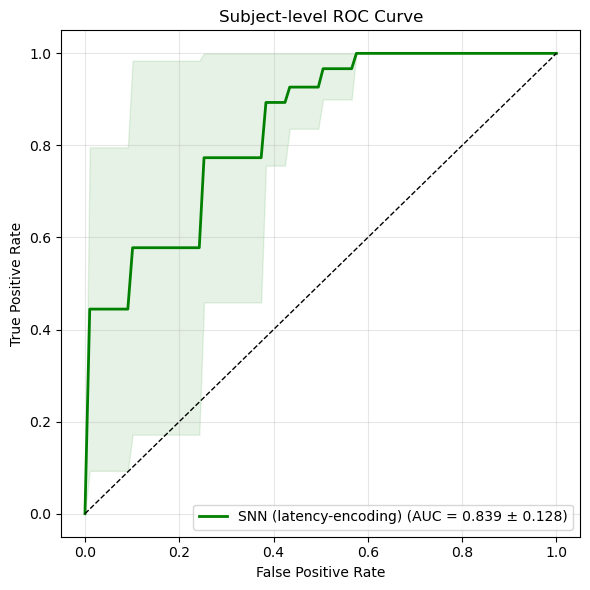

Successfully processed 5 folds for win-level evaluation.


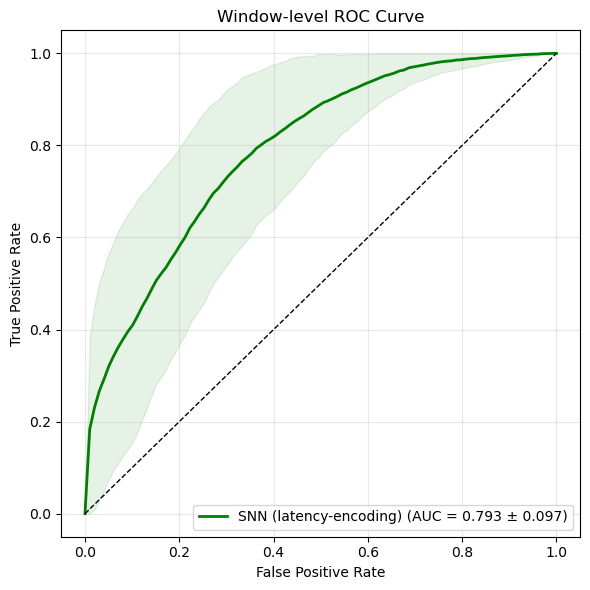

In [11]:
import glob
import json
import os
import re
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import auc, roc_curve

# =================================================================
# SET YOUR CURRENT CONFIGURATION HERE
# Options: "ANN", "SNN (rate-encoding)", "SNN (latency-encoding)"
# =================================================================
CURRENT_MODEL = "SNN (latency-encoding)"
MODEL_COLOR = "green"  # blue for ANN, red for SNN-rate, green for SNN-latency

# Shared False Positive Rate space for mean curve interpolation
mean_fpr = np.linspace(0, 1, 100)


def process_current_experiment(ytrue_key, proba_key):
    """Finds all v1_fold_* files in the directory, calculates TPRs and AUCs per fold,

    and returns the interpolation data for the active experiment.
    """
    pattern = "./v1_fold_*_results*.json"
    fold_files = sorted(glob.glob(pattern))

    if not fold_files:
        raise FileNotFoundError(
            f"Could not find any files matching {pattern} in the current directory."
        )

    fold_tprs = []
    fold_aucs = []

    for f in fold_files:
        with open(f) as file:
            data = json.load(file)

        ytrue = np.array(data[ytrue_key])
        proba = np.array(data[proba_key])

        # Compute ROC for this specific fold
        fpr, tpr, _ = roc_curve(ytrue, proba)

        # Interpolate TPR values to match our shared mean_fpr space
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0  # Force start boundaries
        fold_tprs.append(interp_tpr)

        # Calculate fold AUC
        fold_aucs.append(auc(fpr, tpr))

    print(
        f"Successfully processed {len(fold_files)} folds for {ytrue_key.split('_')[0]}-level evaluation."
    )

    # Calculate statistics across all discovered folds
    tprs = np.array(fold_tprs)
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0  # Force end boundaries

    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)
    std_tpr = np.std(tprs, axis=0)

    return mean_tpr, mean_auc, std_auc, std_tpr


# Ensure output directory exists
os.makedirs("plots4", exist_ok=True)

# ==========================================
# PART 1: Subject-level ROC Curve Generation
# ==========================================
try:
    mean_tpr, mean_auc, std_auc, std_tpr = process_current_experiment(
        "subj_ytrue", "subj_proba"
    )

    plt.figure(figsize=(6, 6))
    plt.plot(
        mean_fpr,
        mean_tpr,
        lw=2,
        color=MODEL_COLOR,
        label=f"{CURRENT_MODEL} (AUC = {mean_auc:.3f} ± {std_auc:.3f})",
    )
    plt.fill_between(
        mean_fpr,
        np.maximum(mean_tpr - std_tpr, 0),
        np.minimum(mean_tpr + std_tpr, 1),
        alpha=0.1,
        color=MODEL_COLOR,
    )

    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Subject-level ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig("plots4/roc_combined_subject.pdf", bbox_inches="tight")
    plt.savefig("plots4/roc_combined_subject.png", dpi=300, bbox_inches="tight")
    plt.show()

except Exception as e:
    print(f"Skipping Subject-level plot due to error: {e}")


# ==========================================
# PART 2: Window-level ROC Curve Generation
# ==========================================
try:
    mean_tpr, mean_auc, std_auc, std_tpr = process_current_experiment(
        "win_ytrue", "win_proba"
    )

    plt.figure(figsize=(6, 6))
    plt.plot(
        mean_fpr,
        mean_tpr,
        lw=2,
        color=MODEL_COLOR,
        label=f"{CURRENT_MODEL} (AUC = {mean_auc:.3f} ± {std_auc:.3f})",
    )
    plt.fill_between(
        mean_fpr,
        np.maximum(mean_tpr - std_tpr, 0),
        np.minimum(mean_tpr + std_tpr, 1),
        alpha=0.1,
        color=MODEL_COLOR,
    )

    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Window-level ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig("plots4/roc_combined_window.pdf", bbox_inches="tight")
    plt.savefig("plots4/roc_combined_window.png", dpi=300, bbox_inches="tight")
    plt.show()

except Exception as e:
    print(f"Skipping Window-level plot due to error: {e}")

In [19]:
import glob, os, re

def parse_energy_summary(path):
    text = open(path).read()
    result = {}
    for line in text.splitlines():
        # look for lines with numbers
        m = re.search(r'([\w\s]+):\s*([\d.]+)\s*(\w+)?', line)
        if m:
            result[m.group(1).strip()] = (m.group(2), m.group(3) or "")
    return text  # return raw for now

# show one to understand the format
sample = sorted(glob.glob("./reports_fold_*/**/summary_energy_report.rpt", recursive=True))
if sample:
    print(open(sample[0]).read())
else:
    print(open(sorted(glob.glob("./reports/**/summary_energy_report.rpt", recursive=True))[0]).read())

Summary energy file
-------------------

Energy used by chips during runtime is 1137.6176199111042 Joules (over 59.5 seconds)
Energy used by FPGAs is 0.0 Joules over the entire time the machine was booted (over 155.818784 seconds)
Energy used by FPGAs is 0.0 Joules over the runtime period (over 59.5 seconds)
Energy used by outside router / cooling during the runtime period is 6961.5 Joules
Energy used by packet transmissions is 0.0 Joules (over 189.04328099999998 seconds)
Energy used during the mapping process is 3887.2661490000005 Joules (over 33.224497 seconds)
Energy used by the data generation process is 0.0 Joules (over 0.0 milliseconds)
Energy used during the loading process is 8616.994722358831 Joules (over 50.855158 seconds)
Energy used during the data extraction process is 17878.94450341242 Joules (over 104.963626 seconds)
Total energy used by the simulation over 189043.281 milliseconds is:
     38482.322994682356 Joules, or
     203.56355852013783 estimated average Watts, or


In [20]:
import glob, re, os

def parse_summary(path):
    text = open(path).read()
    result = {}
    
    # chip runtime energy
    for line in text.splitlines():
        m = re.search(r'([\d.]+)\s*Joules.*?over\s*([\d.]+)\s*seconds', line)
        if m and "runtime" in line.lower() and "chip" in line.lower():
            result["chip_runtime_J"] = float(m.group(1))
            result["runtime_sec"]    = float(m.group(2))

    # total energy — appears on the line after "Total energy used"
    # format: "     37605.66 Joules, or"
    lines = text.splitlines()
    for i, line in enumerate(lines):
        if "Total energy" in line:
            # next non-empty line has the joules
            for j in range(i+1, min(i+4, len(lines))):
                m2 = re.search(r'([\d.]+)\s*Joules', lines[j])
                if m2:
                    result["total_J"] = float(m2.group(1))
                    break
        if "kWh" in line:
            m3 = re.search(r'([\d.]+)\s*kWh', line)
            if m3: result["total_kWh"] = float(m3.group(1))
        if "Watts" in line:
            m4 = re.search(r'([\d.]+)\s*estimated', line)
            if m4: result["avg_W"] = float(m4.group(1))
    
    return result

print(f"{'Fold':<6} {'Batch':<6} {'Runtime(s)':<12} {'Chip(J)':<12} {'Total(J)':<12} {'kWh'}")
print("-" * 65)

fold_totals = {}
for fold_dir in sorted(glob.glob("./reports_fold_*")):
    fold_num = os.path.basename(fold_dir).replace("reports_fold_", "")
    summaries = sorted(glob.glob(f"{fold_dir}/**/summary_energy_report.rpt", recursive=True))
    
    fold_chip_J = fold_total_J = fold_kwh = fold_runtime = 0
    for i, s in enumerate(summaries):
        p = parse_summary(s)
        fold_chip_J   += p.get("chip_runtime_J", 0)
        fold_total_J  += p.get("total_J", 0)
        fold_kwh      += p.get("total_kWh", 0)
        fold_runtime  += p.get("runtime_sec", 0)
        print(f"  {fold_num:<4} {i+1:<6} {p.get('runtime_sec',0):<12.1f} {p.get('chip_runtime_J',0):<12.1f} {p.get('total_J',0):<12.1f} {p.get('total_kWh',0):.6f}")
    
    fold_totals[fold_num] = {"chip_J": fold_chip_J, "total_J": fold_total_J, "kWh": fold_kwh, "runtime_s": fold_runtime}
    print(f"  {'FOLD '+fold_num+' TOTAL':<10} {fold_runtime:<12.1f} {fold_chip_J:<12.1f} {fold_total_J:<12.1f} {fold_kwh:.6f}")
    print()

print("\n=== Summary per fold ===")
all_total_J = all_kwh = 0
for fold_num, v in fold_totals.items():
    print(f"  Fold {fold_num}: {v['total_J']:.1f} J  ({v['kWh']:.4f} kWh)  runtime={v['runtime_s']:.0f}s")
    all_total_J += v["total_J"]
    all_kwh     += v["kWh"]
print(f"\n  ALL FOLDS TOTAL: {all_total_J:.1f} J  ({all_kwh:.4f} kWh)")

Fold   Batch  Runtime(s)   Chip(J)      Total(J)     kWh
-----------------------------------------------------------------
  0    1      59.5         1137.6       38482.3      0.010690
  0    2      59.5         1135.5       33472.6      0.009298
  0    3      59.5         1133.4       33987.0      0.009441
  0    4      59.5         1131.3       38827.4      0.010785
  0    5      59.5         1144.0       32277.7      0.008966
  0    6      59.5         1133.4       35737.6      0.009927
  0    7      59.5         1144.0       34746.2      0.009652
  0    8      59.5         1133.4       33296.3      0.009249
  0    9      4.2          79.8         16971.2      0.004714
  FOLD 0 TOTAL 480.2        9172.3       297798.4     0.082722

  0_v1 1      59.5         1137.6       32397.4      0.008999
  0_v1 2      59.5         1137.6       32158.6      0.008933
  0_v1 3      59.5         1133.4       36626.6      0.010174
  0_v1 4      59.5         1135.5       35108.7      0.009752
  0_v1 